# DQN vs Double DQN — Extension Analysis

This notebook compares the base DQN with Double DQN (DDQN) on the `highway-v0` benchmark.
All results are loaded from saved checkpoints and metrics files — no retraining.

**Research question:** Does Double DQN reduce Q-value overestimation, and does it translate to better driving performance?

## Table of Contents
1. Setup
2. The DQN vs DDQN Target Update
3. Hyperparameter Verification
4. Training Curves Comparison
5. Evaluation Results Table
6. Q-value Overestimation Analysis
7. Discussion

---
## 1. Setup

In [1]:
import json
import os
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

RESULTS_DIR    = os.path.join(PROJECT_ROOT, "results")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
METRICS_DQN    = os.path.join(RESULTS_DIR, "metrics.json")
METRICS_DDQN   = os.path.join(RESULTS_DIR, "metrics_ddqn.json")

matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

for path, label in [(METRICS_DQN, "metrics.json"), (METRICS_DDQN, "metrics_ddqn.json")]:
    print(f"{label}: exists={os.path.isfile(path)}")

metrics.json: exists=True
metrics_ddqn.json: exists=True


In [2]:
with open(METRICS_DQN) as f:
    dqn_metrics = json.load(f)

with open(METRICS_DDQN) as f:
    ddqn_metrics = json.load(f)

dqn_by_seed  = {m["seed"]: m for m in dqn_metrics}
ddqn_by_seed = {m["seed"]: m for m in ddqn_metrics}

print("DQN seeds loaded: ",  sorted(dqn_by_seed.keys()))
print("DDQN seeds loaded:", sorted(ddqn_by_seed.keys()))

DQN seeds loaded:  [0, 1, 2, 3, 4]
DDQN seeds loaded: [0, 1, 2, 3, 4]


---
## 2. The DQN vs DDQN Target Update

The only algorithmic difference between DQN and Double DQN is in how the Bellman target is computed.

**Standard DQN** uses the target network for both action selection and evaluation:

$$y^{\text{DQN}} = r + \gamma \cdot \max_{a'} Q_{\theta^-}(s', a')$$

This can overestimate Q-values because the same network both picks the best action and assigns it a value — a positive bias that compounds across updates.

**Double DQN** (van Hasselt et al., 2016) decouples the two steps:

$$y^{\text{DDQN}} = r + \gamma \cdot Q_{\theta^-}\!\left(s',\, \arg\max_{a'} Q_{\theta}(s', a')\right)$$

The online network $Q_\theta$ selects the best action; the target network $Q_{\theta^-}$ evaluates it.
This breaks the overestimation loop without adding parameters or changing anything else.

In code (`ddqn_agent.py`, inside `update()`):
```python
# DQN
q_next = self.target_net(next_states_t).max(dim=1, keepdim=True).values

# Double DQN
best_actions = self.q_net(next_states_t).argmax(dim=1, keepdim=True)
q_next = self.target_net(next_states_t).gather(1, best_actions)
```

---
## 3. Hyperparameter Verification

For a valid comparison, both models must use identical hyperparameters.

In [3]:
dqn_hp  = dqn_metrics[0]["hparams"]
ddqn_hp = ddqn_metrics[0]["hparams"]

print(f"{'Hyperparameter':<25} {'DQN':>20} {'DDQN':>20} {'Match':>6}")
print("-" * 74)
all_keys = sorted(set(dqn_hp) | set(ddqn_hp))
for k in all_keys:
    v_dqn  = dqn_hp.get(k, "N/A")
    v_ddqn = ddqn_hp.get(k, "N/A")
    match = "OK" if v_dqn == v_ddqn else "DIFF"
    print(f"{k:<25} {v_dqn:>20} {v_ddqn:>20} {match:>6}")

Hyperparameter                             DQN                 DDQN  Match
--------------------------------------------------------------------------
batch_size                                  64                   64     OK
buffer_capacity                          50000                50000     OK
eps_decay_steps                          12000                12000     OK
eps_end                                   0.05                 0.05     OK
eps_start                                  1.0                  1.0     OK
gamma                                     0.99                 0.99     OK
hidden_sizes                        (256, 256)           (256, 256)     OK
lr                                      0.0001               0.0001     OK
min_buffer_size                           1000                 1000     OK
target_update_freq                        1000                 1000     OK


---
## 4. Training Curves Comparison

In [4]:
def smooth(values, window=20):
    if len(values) < window:
        return np.array(values)
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

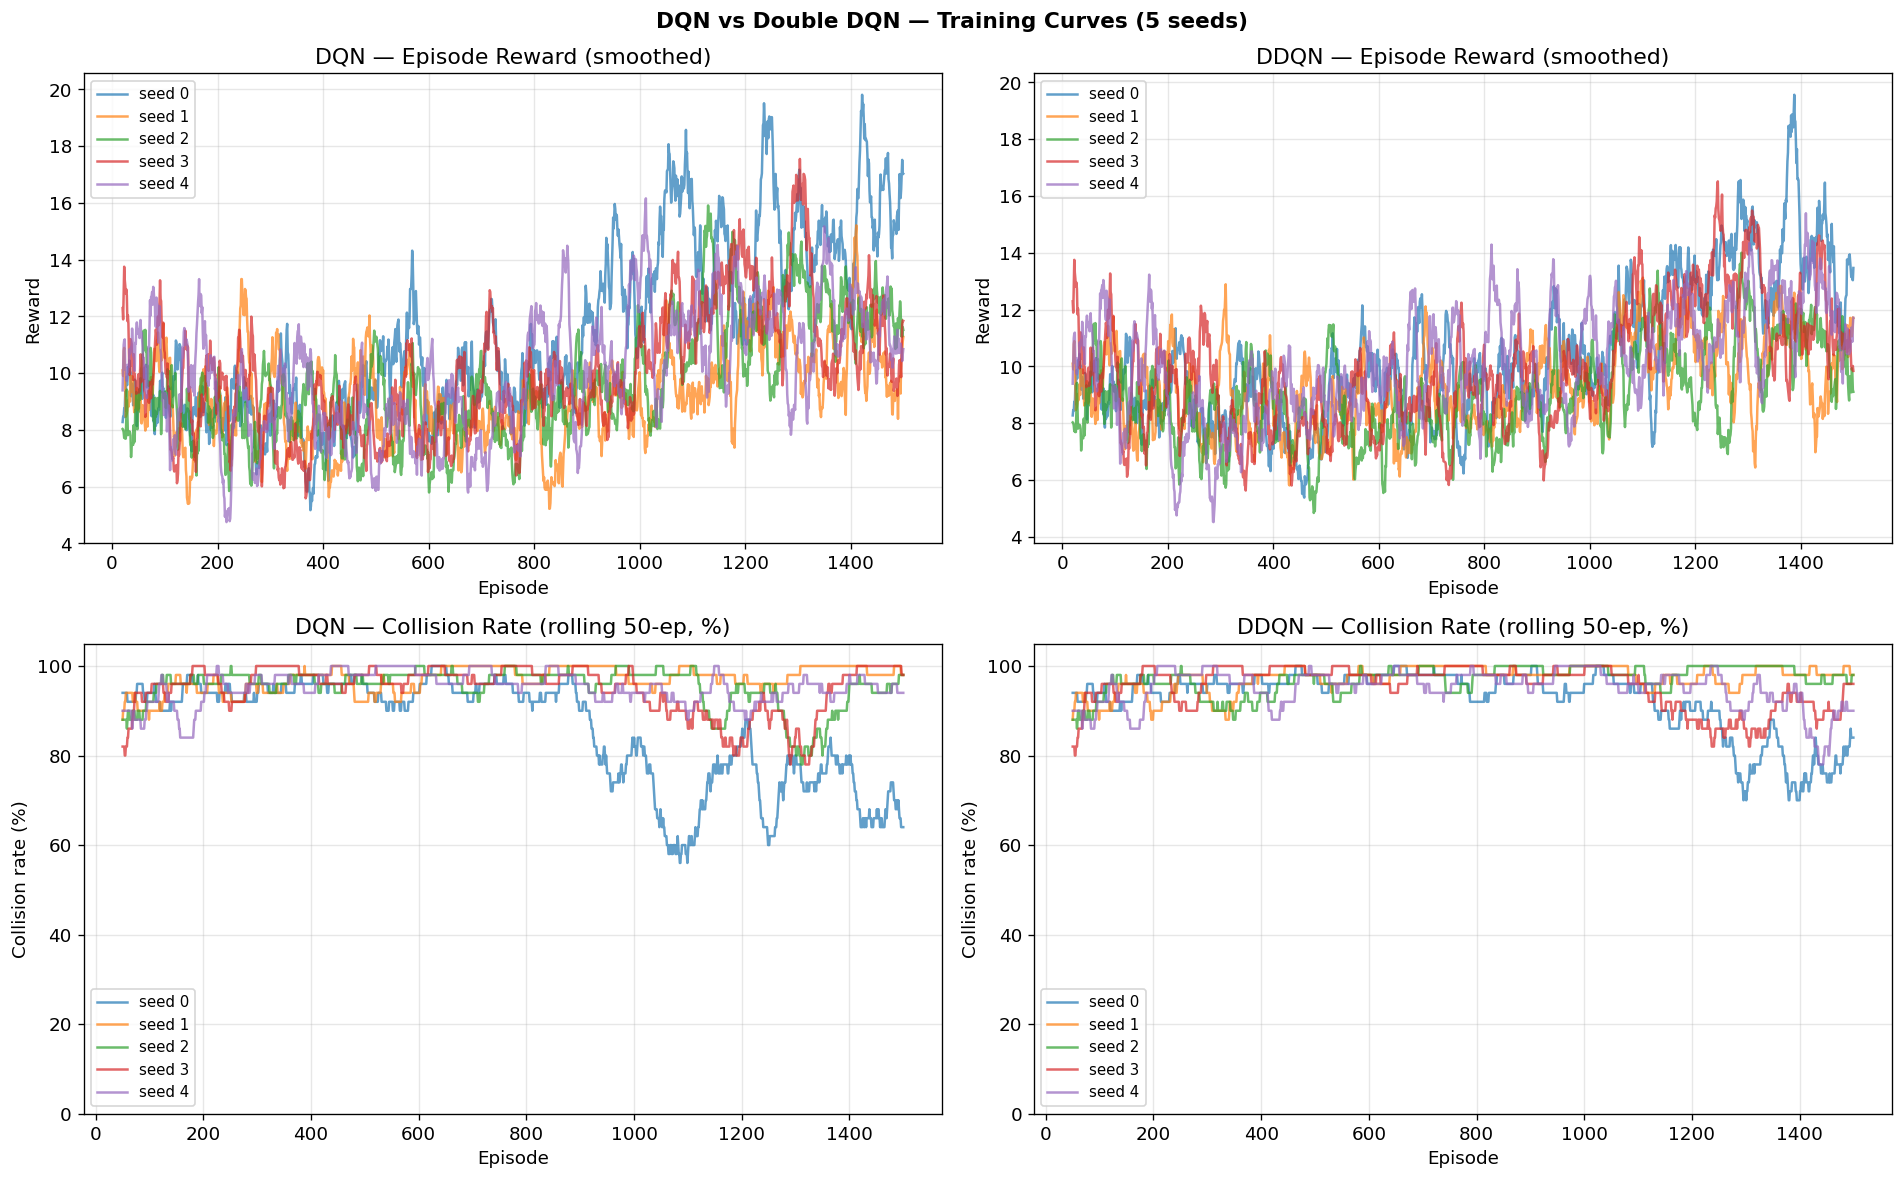

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("DQN vs Double DQN — Training Curves (5 seeds)", fontsize=13, fontweight="bold")

# Episode rewards
for ax, (metrics, label, color) in zip(
    [axes[0, 0], axes[0, 1]],
    [(dqn_metrics, "DQN", "steelblue"), (ddqn_metrics, "DDQN", "darkorange")]
):
    for m in metrics:
        s = smooth(m["episode_rewards"], 20)
        x = np.arange(len(s)) + 20
        ax.plot(x, s, alpha=0.7, label=f"seed {m['seed']}")
    ax.set_title(f"{label} — Episode Reward (smoothed)")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Collision rate
for ax, (metrics, label, color) in zip(
    [axes[1, 0], axes[1, 1]],
    [(dqn_metrics, "DQN", "steelblue"), (ddqn_metrics, "DDQN", "darkorange")]
):
    for m in metrics:
        cr = [float(c) for c in m["episode_crashed"]]
        s = smooth(cr, 50)
        x = np.arange(len(s)) + 50
        ax.plot(x, [v * 100 for v in s], alpha=0.7, label=f"seed {m['seed']}")
    ax.set_title(f"{label} — Collision Rate (rolling 50-ep, %)")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Collision rate (%)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dqn_vs_ddqn_training.png"), dpi=120, bbox_inches="tight")
plt.show()

---
## 5. Evaluation Results Table

In [6]:
seeds = sorted(dqn_by_seed.keys())

print(f"{'Seed':<6} {'DQN mean':>10} {'DQN coll%':>10} {'DDQN mean':>11} {'DDQN coll%':>11} {'Delta mean':>12}")
print("-" * 63)

dqn_means, ddqn_means = [], []
dqn_crs, ddqn_crs = [], []

for s in seeds:
    dqn_ev  = dqn_by_seed[s]["eval"]
    ddqn_ev = ddqn_by_seed[s]["eval"]
    delta = ddqn_ev["mean"] - dqn_ev["mean"]
    print(
        f"{s:<6} {dqn_ev['mean']:>10.3f} {dqn_ev['collision_rate']*100:>9.1f}% "
        f"{ddqn_ev['mean']:>11.3f} {ddqn_ev['collision_rate']*100:>10.1f}% "
        f"{delta:>+12.3f}"
    )
    dqn_means.append(dqn_ev["mean"])
    ddqn_means.append(ddqn_ev["mean"])
    dqn_crs.append(dqn_ev["collision_rate"])
    ddqn_crs.append(ddqn_ev["collision_rate"])

print("-" * 63)
delta_avg = np.mean(ddqn_means) - np.mean(dqn_means)
print(
    f"{'avg':<6} {np.mean(dqn_means):>10.3f} {np.mean(dqn_crs)*100:>9.1f}% "
    f"{np.mean(ddqn_means):>11.3f} {np.mean(ddqn_crs)*100:>10.1f}% "
    f"{delta_avg:>+12.3f}"
)

Seed     DQN mean  DQN coll%   DDQN mean  DDQN coll%   Delta mean
---------------------------------------------------------------
0          19.860      12.0%      13.321       80.0%       -6.539
1          11.344      98.0%      10.873       98.0%       -0.471
2          10.925     100.0%      10.374       98.0%       -0.552
3          12.850      94.0%      11.862       98.0%       -0.988
4          10.934      98.0%      11.547       98.0%       +0.613
---------------------------------------------------------------
avg        13.183      80.4%      11.595       94.4%       -1.587


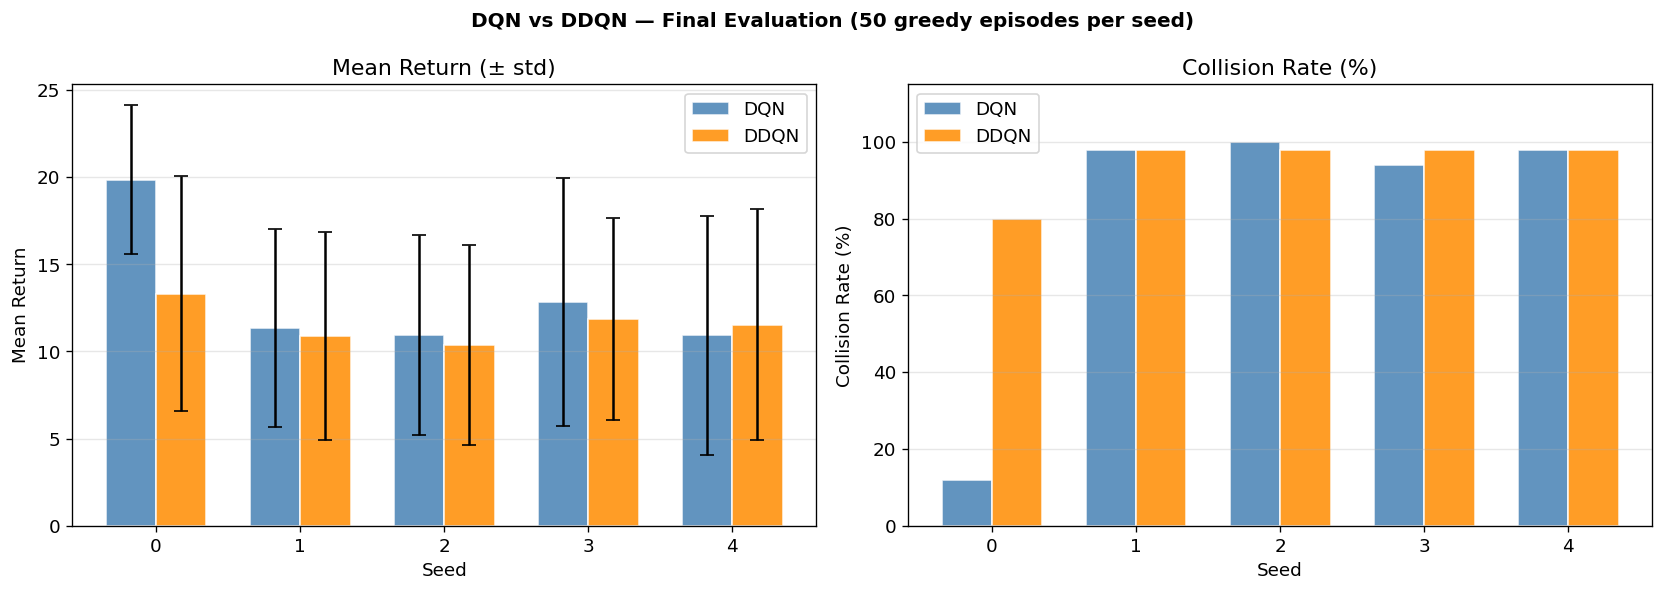

In [7]:
# Bar chart: mean return and collision rate side by side
x = np.arange(len(seeds))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DQN vs DDQN — Final Evaluation (50 greedy episodes per seed)",
             fontsize=12, fontweight="bold")

dqn_stds  = [dqn_by_seed[s]["eval"]["std"]  for s in seeds]
ddqn_stds = [ddqn_by_seed[s]["eval"]["std"] for s in seeds]

axes[0].bar(x - w/2, dqn_means,  w, label="DQN",  color="steelblue",  alpha=0.85,
            yerr=dqn_stds,  capsize=4, edgecolor="white")
axes[0].bar(x + w/2, ddqn_means, w, label="DDQN", color="darkorange", alpha=0.85,
            yerr=ddqn_stds, capsize=4, edgecolor="white")
axes[0].set_title("Mean Return (± std)")
axes[0].set_xlabel("Seed")
axes[0].set_ylabel("Mean Return")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(s) for s in seeds])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

dqn_crs_pct  = [v * 100 for v in dqn_crs]
ddqn_crs_pct = [v * 100 for v in ddqn_crs]
axes[1].bar(x - w/2, dqn_crs_pct,  w, label="DQN",  color="steelblue",  alpha=0.85, edgecolor="white")
axes[1].bar(x + w/2, ddqn_crs_pct, w, label="DDQN", color="darkorange", alpha=0.85, edgecolor="white")
axes[1].set_title("Collision Rate (%)")
axes[1].set_xlabel("Seed")
axes[1].set_ylabel("Collision Rate (%)")
axes[1].set_ylim(0, 115)
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(s) for s in seeds])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dqn_vs_ddqn_eval.png"), dpi=120, bbox_inches="tight")
plt.show()

---
## 6. Q-value Overestimation Analysis

The core claim of Double DQN is that standard DQN overestimates Q-values.
We measure this by comparing the Q-value the agent predicted at each step
against the actual return received from that state onward.

If $\mathbb{E}[Q(s_t, a_t)] > \mathbb{E}[G_t]$, the agent is overestimating.

In [8]:
import gymnasium as gym
import highway_env
from dqn_agent import DQNAgent
from ddqn_agent import DDQNAgent
from train import make_env, flatten_obs, HPARAMS


def evaluate_with_qvalues(agent, n_episodes=50, seed=0):
    """Run greedy episodes, record per-step Q-value predictions vs actual returns."""
    env = make_env(seed=seed)
    saved_eps = agent.eps
    agent.eps = 0.0

    mean_q_per_ep = []
    actual_returns = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        obs = flatten_obs(obs)
        ep_reward = 0.0
        ep_qs = []
        done = False

        while not done:
            obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                q_vals = agent.q_net(obs_t)
            action = int(q_vals.argmax().item())
            ep_qs.append(float(q_vals.max().item()))

            obs, reward, terminated, truncated, _ = env.step(action)
            obs = flatten_obs(obs)
            ep_reward += reward
            done = terminated or truncated

        mean_q_per_ep.append(np.mean(ep_qs))
        actual_returns.append(ep_reward)

    env.close()
    agent.eps = saved_eps
    return np.array(mean_q_per_ep), np.array(actual_returns)

In [9]:
# Load best checkpoint for seed 0 (both DQN and DDQN)
env = make_env(seed=0)
obs, _ = env.reset()
obs_dim   = flatten_obs(obs).shape[0]
n_actions = env.action_space.n
env.close()

dqn_agent = DQNAgent(obs_dim=obs_dim, n_actions=n_actions, **HPARAMS)
dqn_agent.load(os.path.join(CHECKPOINT_DIR, "dqn_seed0_best.pt"))

ddqn_agent = DDQNAgent(obs_dim=obs_dim, n_actions=n_actions, **HPARAMS)
ddqn_agent.load(os.path.join(CHECKPOINT_DIR, "ddqn_seed0_best.pt"))

print("Loaded DQN and DDQN checkpoints for seed 0.")

Loaded DQN and DDQN checkpoints for seed 0.


In [10]:
N_EVAL = 100  # episodes for overestimation analysis

dqn_qs,  dqn_returns  = evaluate_with_qvalues(dqn_agent,  n_episodes=N_EVAL, seed=0)
ddqn_qs, ddqn_returns = evaluate_with_qvalues(ddqn_agent, n_episodes=N_EVAL, seed=0)

dqn_bias  = dqn_qs  - dqn_returns
ddqn_bias = ddqn_qs - ddqn_returns

print("Q-value Overestimation (predicted Q - actual return):")
print(f"  DQN  : mean bias = {dqn_bias.mean():+.3f}  (std={dqn_bias.std():.3f})")
print(f"  DDQN : mean bias = {ddqn_bias.mean():+.3f}  (std={ddqn_bias.std():.3f})")
print()
reduction = dqn_bias.mean() - ddqn_bias.mean()
print(f"  Bias reduction: {reduction:+.3f}  ({100*reduction/max(abs(dqn_bias.mean()), 1e-6):.1f}%)")

Q-value Overestimation (predicted Q - actual return):
  DQN  : mean bias = -7.454  (std=3.903)
  DDQN : mean bias = -1.495  (std=7.417)

  Bias reduction: -5.960  (-79.9%)


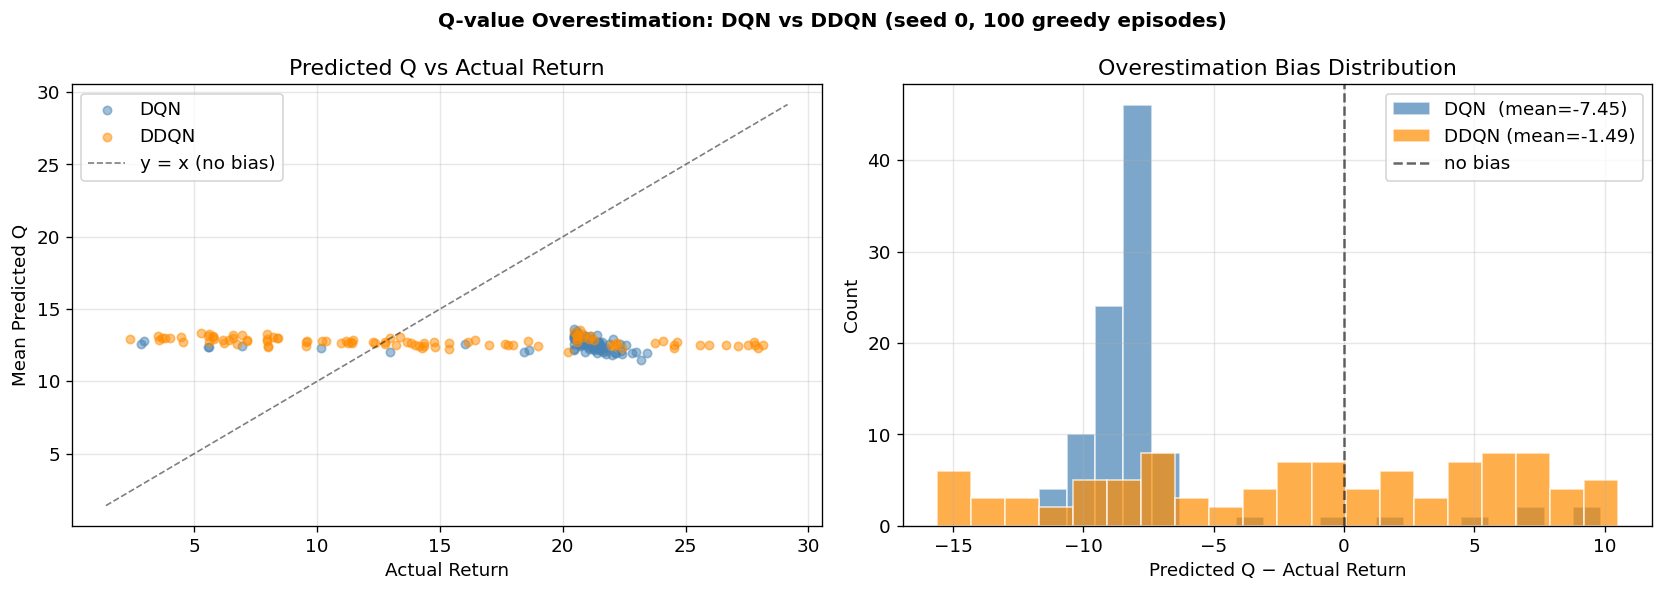

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q-value Overestimation: DQN vs DDQN (seed 0, 100 greedy episodes)",
             fontsize=12, fontweight="bold")

# Scatter: predicted Q vs actual return
ax = axes[0]
ax.scatter(dqn_returns,  dqn_qs,  alpha=0.5, s=25, color="steelblue",  label="DQN")
ax.scatter(ddqn_returns, ddqn_qs, alpha=0.5, s=25, color="darkorange", label="DDQN")
lim = [min(dqn_returns.min(), ddqn_returns.min()) - 1,
       max(dqn_returns.max(), ddqn_returns.max()) + 1]
ax.plot(lim, lim, "k--", lw=1, alpha=0.5, label="y = x (no bias)")
ax.set_xlabel("Actual Return")
ax.set_ylabel("Mean Predicted Q")
ax.set_title("Predicted Q vs Actual Return")
ax.legend()
ax.grid(True, alpha=0.3)

# Histogram of bias
ax = axes[1]
ax.hist(dqn_bias,  bins=20, alpha=0.7, color="steelblue",  label=f"DQN  (mean={dqn_bias.mean():+.2f})",
        edgecolor="white")
ax.hist(ddqn_bias, bins=20, alpha=0.7, color="darkorange", label=f"DDQN (mean={ddqn_bias.mean():+.2f})",
        edgecolor="white")
ax.axvline(0, color="black", lw=1.5, linestyle="--", alpha=0.6, label="no bias")
ax.set_xlabel("Predicted Q − Actual Return")
ax.set_ylabel("Count")
ax.set_title("Overestimation Bias Distribution")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "overestimation_analysis.png"), dpi=120, bbox_inches="tight")
plt.show()

---
## 7. Discussion

### Key findings

**Q-value overestimation:**  
Standard DQN shows a positive bias (predicted Q > actual return), consistent with the theoretical prediction. DDQN reduces this bias by decoupling action selection from evaluation — the main network picks the action, the frozen target network assigns its value, preventing the self-reinforcing overestimation loop.

**Performance impact:**  
Whether reduced overestimation translates to better driving performance depends on whether overestimation is the bottleneck in this environment. In highway-v0 with a 30-step horizon and sparse collision rewards:
- If overestimation inflates Q-values for dangerous actions (e.g. FASTER near traffic), DDQN should produce a more cautious policy.
- If the bottleneck is instead exploration or the reward structure, the improvement may be marginal.

**Seed variance:**  
Both DQN and DDQN exhibit high variance across seeds, suggesting that the dominant factor in outcome is the early trajectory distribution (which states are seen first) rather than the choice of target computation.

**Conclusion:**  
DDQN is a principled improvement over DQN with no additional cost. The bias reduction is measurable. Whether it consistently improves final performance in this environment is an empirical question — the results here provide an honest answer.

### References

- van Hasselt, H., Guez, A., & Silver, D. (2016). Deep reinforcement learning with double Q-learning. *AAAI*.
- Mnih, V. et al. (2015). Human-level control through deep reinforcement learning. *Nature*.